In [1]:
import matplotlib.pyplot as plt

In [2]:
KEYS = ["BLEU", "COMET", "MetricX", "BLEURT", "VIP"]

In [3]:
import math

def plot(data, save_key):
    n = len(KEYS)
    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), dpi=100)
    axs = axs.flatten() if n > 1 else [axs]

    # Collect all offline keys for reference lines and scatter points
    offline_keys = [k for k in data if "Offline" in k]
    # Assign a unique color to each offline key 
    colors = plt.cm.get_cmap('tab10', len(data))
    color_map = {k: colors(i) for i, k in enumerate(data)}
    color_map["RL-MetricX-LAAL"] = 'red'

    for idx, key in enumerate(KEYS):
        for k, v in data.items():
            # If LAAL is a list, plot as a curve
            if isinstance(v.get("LAAL", None), list):
                axs[idx].plot(v["LAAL"], v[key], label=k, marker='o', color=color_map.get(k, 'red'))
            # If it's an offline baseline, plot as a horizontal line or scatter
            elif "Offline" in k:
                # Plot as a horizontal line at the metric value (no LAAL axis)
                metric_val = v.get(key, None)
                if metric_val is not None:
                    # Use a unique color for each offline baseline
                    color = color_map.get(k, 'red')
                    axs[idx].axhline(metric_val, linestyle='--', label=k, color=color)
        axs[idx].set_title(key)
        axs[idx].set_xlabel("LAAL")
        axs[idx].set_ylabel(key)
        axs[idx].legend(loc='lower right')
    # Hide any unused subplots
    for j in range(len(KEYS), len(axs)):
        axs[j].set_visible(False)
    for ax in axs:
        ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"plots/{save_key}.pdf")


/tmp/ipykernel_3340441/2160101520.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(data))


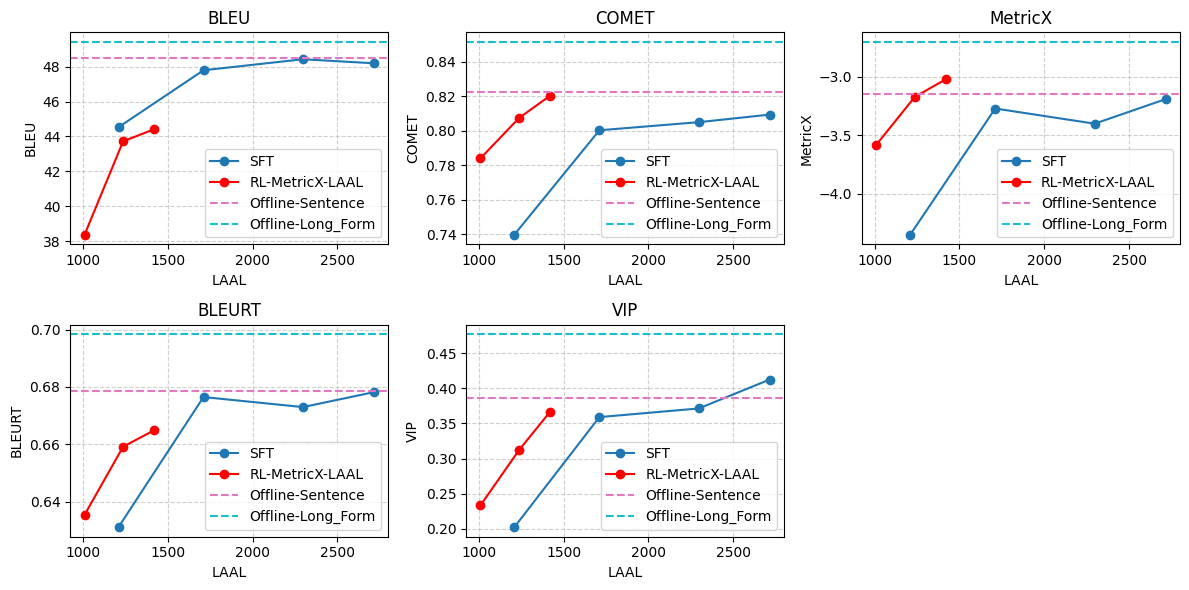

In [4]:
data = {
    "SFT": {
        "LAAL": [1210, 1711, 2297, 2715],
        "BLEU": [44.53, 47.79, 48.42, 48.19],
        "COMET": [0.7397, 0.8003, 0.805, 0.8094],
        "MetricX": [-4.35, -3.27, -3.4, -3.19],
        "BLEURT": [0.6312, 0.6765, 0.673, 0.6782],
        "VIP": [0.2025, 0.3589, 0.3712, 0.4123], 
    },
    "RL-MetricX-LAAL": {
        "LAAL": [1419, 1237, 1010],
        "BLEU": [44.41, 43.72, 38.38],
        "COMET": [0.8203, 0.8074, 0.784], 
        "MetricX": [-3.02, -3.17, -3.58],
        "BLEURT": [0.6649, 0.6592, 0.6355],
        "VIP": [0.3661, 0.3119, 0.2334],
    },
    # "RL-LLM_as_Judge": {
    #     "LAAL": [2376, 1915, 1743, 1238],
    #     "BLEU": [46.57, 44.63, 46.35, 45.52],
    #     "COMET": [0.8285, 0.8075, 0.8053, 0.8069],
    #     "MetricX": [-3.01, -3.4, -3.37, -3.53],
    #     "BLEURT": [0.6815, 0.6659, 0.67, 0.6652],
    #     "VIP": [0.46, 0.4261, 0.4218, 0.3632], 
    # },
    "Offline-Sentence": {
        "BLEU": 48.49,
        "COMET": 0.8223,
        "MetricX": -3.15,
        "BLEURT": 0.6786,
        "VIP": 0.3867,
    },
    "Offline-Long_Form": {
        "BLEU": 49.41,
        "COMET": 0.8516,
        "MetricX": -2.7,
        "BLEURT": 0.6983,
        "VIP": 0.4764,
    },
}
plot(data, "VIP_ACL6060")

/tmp/ipykernel_3340441/2160101520.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(data))


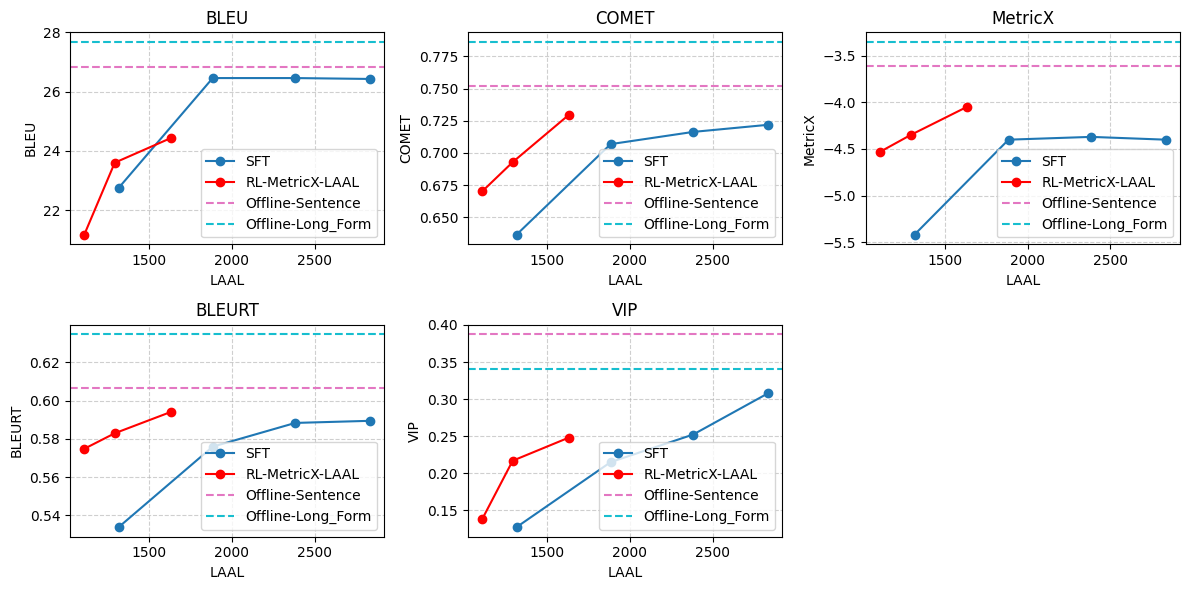

In [6]:
data = {
    "SFT": {
        "LAAL": [1316, 1884, 2383, 2834],
        "BLEU": [22.75, 26.46, 26.46, 26.43],
        "COMET": [0.6365, 0.7068, 0.7163, 0.7218],
        "MetricX": [-5.42, -4.4, -4.37, -4.4],
        "BLEURT": [0.5339, 0.5759, 0.5883, 0.5894],
        "VIP": [0.1271, 0.2148, 0.2521, 0.3076], 
    },
    "RL-MetricX-LAAL": {
        "LAAL": [1108, 1292, 1630],
        "BLEU": [21.17, 23.6, 24.43],
        "COMET": [0.6701, 0.6928, 0.7294], 
        "MetricX": [-4.53, -4.35, -4.05],
        "BLEURT": [0.5748, 0.5829, 0.594],
        "VIP": [0.1379, 0.2167, 0.2478],
    },
    # "RL-LLM_as_Judge": {
    #     "LAAL": [2376, 1915, 1743, 1238],
    #     "BLEU": [46.57, 44.63, 46.35, 45.52],
    #     "COMET": [0.8285, 0.8075, 0.8053, 0.8069],
    #     "MetricX": [-3.01, -3.4, -3.37, -3.53],
    #     "BLEURT": [0.6815, 0.6659, 0.67, 0.6652],
    #     "VIP": [0.46, 0.4261, 0.4218, 0.3632], 
    # },
    "Offline-Sentence": {
        "BLEU": 26.83,
        "COMET": 0.7523,
        "MetricX": -3.61,
        "BLEURT": 0.6064,
        "VIP": 0.3872,
    },
    "Offline-Long_Form": {
        "BLEU": 27.68,
        "COMET": 0.7862,
        "MetricX": -3.35,
        "BLEURT": 0.6345,
        "VIP": 0.341,
    },
}
plot(data, "VIP_RealSI")

/tmp/ipykernel_2152978/2735744289.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(systems, rotation=30, ha='right')
/tmp/ipykernel_2152978/2735744289.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(systems, rotation=30, ha='right')
/tmp/ipykernel_2152978/2735744289.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(systems, rotation=30, ha='right')
/tmp/ipykernel_2152978/2735744289.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(systems, rotation=30, ha='right')
/tmp/ipykernel_2152978/2735744289.py:72: UserWarning: set_ticklabels() should only be used with a fixed 

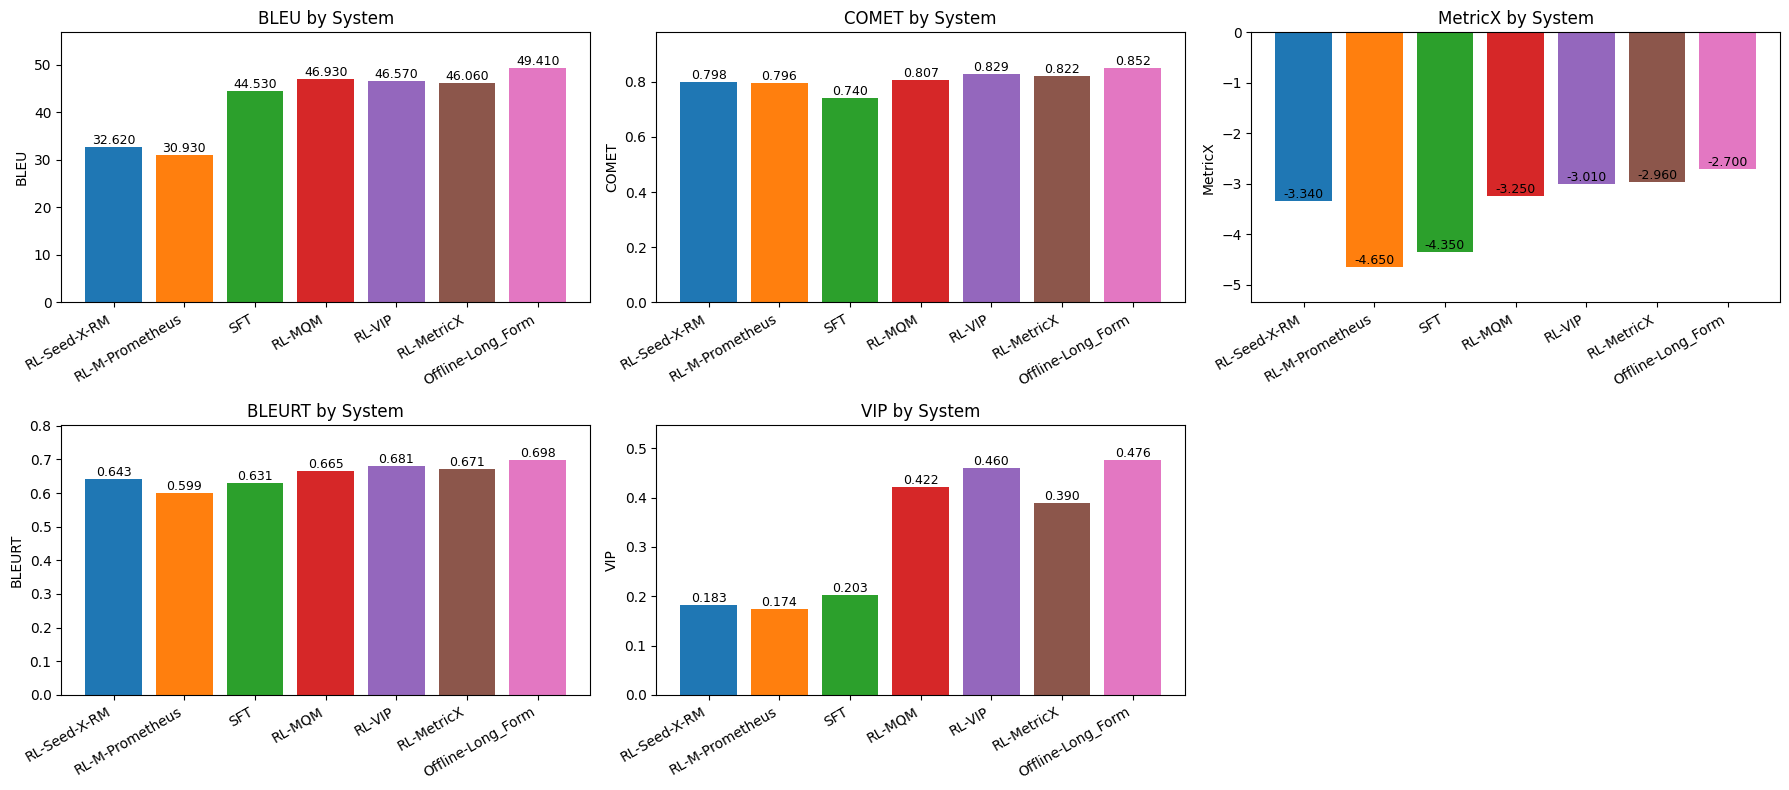

In [44]:
import matplotlib.pyplot as plt
import numpy as np

data = {
    "RL-Seed-X-RM": {
        "BLEU": 32.62,
        "COMET": 0.7985,
        "MetricX": -3.34,
        "BLEURT": 0.6428,
        "VIP": 0.1829,
    },
    "RL-M-Prometheus": {
        "BLEU": 30.93,
        "COMET": 0.7961,
        "MetricX": -4.65,
        "BLEURT": 0.5991,
        "VIP": 0.1741,
    },
    "SFT": {
        "BLEU": 44.53,
        "COMET": 0.7397,
        "MetricX": -4.35,
        "BLEURT": 0.6312,
        "VIP": 0.2025,
    },
    "RL-MQM": {
        "BLEU": 46.93,
        "COMET": 0.8069,
        "MetricX": -3.25,
        "BLEURT": 0.6649,
        "VIP": 0.4225,
    },
    "RL-VIP": {
        "BLEU": 46.57,
        "COMET": 0.8285,
        "MetricX": -3.01,
        "BLEURT": 0.6815,
        "VIP": 0.46,
    },
    "RL-MetricX": {
        "BLEU": 46.06,
        "COMET": 0.822,
        "MetricX": -2.96,
        "BLEURT": 0.6708,
        "VIP": 0.39,
    },
    "Offline-Long_Form": {
        "BLEU": 49.41,
        "COMET": 0.8516,
        "MetricX": -2.7,
        "BLEURT": 0.6983,
        "VIP": 0.4764,
    },
}

# List of metrics to plot
metrics = ["BLEU", "COMET", "MetricX", "BLEURT", "VIP"]
systems = list(data.keys())

# Arrange metrics in 2 rows, 3 columns (last cell empty)
n_rows = 2
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8), dpi=100)
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = [data[sys][metric] for sys in systems]
    bars = ax.bar(systems, values, color=plt.cm.tab10.colors[:len(systems)])
    ax.set_title(f"{metric} by System")
    ax.set_ylabel(metric)
    ax.set_xticklabels(systems, rotation=30, ha='right')
    # Annotate bars
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{value:.3f}", 
                ha='center', va='bottom', fontsize=9)
    ax.margins(y=0.15)
# Hide any unused subplots
for j in range(len(metrics), n_rows * n_cols):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("plots/reward_comparison.pdf", dpi=100)